# 👑 DropQueen
## Notebook 2: Data Cleaning & Feature Engineering
**Project:** AI-Powered Product Demand & Sales Forecasting Engine for TikTok Shop & Amazon  
**Author:** Chastity Lewis  
**Course:** CISC 610 — DevOps and MLOps | Mercy University | Spring 2026  

---

### 📌 Notebook Goals
1. Load the raw datasets from Notebook 1
2. Remove duplicates
3. Handle missing values
4. Remove outliers using IQR method
5. Engineer ML-ready features
6. Encode categorical variables
7. Save the final clean dataset for model training

---

## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('seaborn-v0_8-whitegrid')
GOLD   = '#F59E0B'
BLACK  = '#1F1F1F'
AMBER  = '#B45309'
LIGHT  = '#FDE68A'
COLORS = ['#F59E0B', '#FCD34D', '#B45309', '#FDE68A', '#D97706']

print('✅ Libraries loaded!')

✅ Libraries loaded!


## Step 2: Load Datasets from Notebook 1

In [6]:
from google.colab import files
import io

print('📂 Upload dropqueen_amazon_raw.csv')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_amazon = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ Amazon dataset loaded!')
print(f'   Shape: {df_amazon.shape[0]:,} rows × {df_amazon.shape[1]} columns')
df_amazon.head()

📂 Upload dropqueen_amazon_raw.csv


Saving dropqueen_amazon_raw.csv to dropqueen_amazon_raw.csv

✅ Amazon dataset loaded!
   Shape: 2,023,070 rows × 9 columns


,user_id,product_id,rating,timestamp,date,year,month,week,day_of_week
0,A39HTATAQ9V7YF,0205616461,5.0000,1369699200,2013-05-28,2013,5,22,1
1,A3JM6GV9MNOF9X,0558925278,3.0000,1355443200,2012-12-14,2012,12,50,4
2,A1Z513UWSAAO0F,0558925278,5.0000,1404691200,2014-07-07,2014,7,28,0
3,A1WMRR494NWEWV,0733001998,4.0000,1382572800,2013-10-24,2013,10,43,3
4,A3IAAVS479H7M7,0737104473,1.0000,1274227200,2010-05-19,2010,5,20,2


In [7]:
print('📂 Upload dropqueen_weekly_demand.csv')
uploaded2 = files.upload()
filename2 = list(uploaded2.keys())[0]
df_demand = pd.read_csv(io.BytesIO(uploaded2[filename2]))

print(f'\n✅ Weekly demand dataset loaded!')
print(f'   Shape: {df_demand.shape[0]:,} rows × {df_demand.shape[1]} columns')
df_demand.head()

📂 Upload dropqueen_weekly_demand.csv


Saving dropqueen_weekly_demand.csv to dropqueen_weekly_demand.csv

✅ Weekly demand dataset loaded!
   Shape: 1,504,357 rows × 6 columns


,product_id,year,week,weekly_reviews,avg_weekly_rating,demand_spike
0,0205616461,2013,22,1,5.0000,1
1,0558925278,2012,50,1,3.0000,1
2,0558925278,2014,28,1,5.0000,1
3,0733001998,2013,43,1,4.0000,1
4,0737104473,2010,20,1,1.0000,1


In [8]:
print('📂 Upload dropqueen_tiktok_raw.csv')
uploaded3 = files.upload()
filename3 = list(uploaded3.keys())[0]
df_tiktok = pd.read_csv(io.BytesIO(uploaded3[filename3]))

print(f'\n✅ TikTok dataset loaded!')
print(f'   Shape: {df_tiktok.shape[0]:,} rows × {df_tiktok.shape[1]} columns')
df_tiktok.head()

📂 Upload dropqueen_tiktok_raw.csv


Saving dropqueen_tiktok_raw.csv to dropqueen_tiktok_raw.csv

✅ TikTok dataset loaded!
   Shape: 1,260 rows × 10 columns


,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium
2,Post_10,TikTok,#Gaming,Shorts,India,3898384,8634,69378,42700,Low
3,Post_18,TikTok,#Tech,Shorts,UK,2051091,24472,54704,41737,Medium
4,Post_19,TikTok,#Fashion,Post,USA,3461154,165335,50077,19505,Low


## Step 3: Clean Amazon Dataset

In [9]:
print('🔍 Before Cleaning:')
print(f'   Rows:       {len(df_amazon):,}')
print(f'   Duplicates: {df_amazon.duplicated().sum():,}')
print(f'   Missing:    {df_amazon.isnull().sum().sum():,}')

# Remove duplicates
df_amazon = df_amazon.drop_duplicates()

# Drop rows with missing values
df_amazon = df_amazon.dropna()

# Validate rating range (must be 1-5)
df_amazon = df_amazon[df_amazon['rating'].between(1, 5)]

print(f'\n✅ After Cleaning:')
print(f'   Rows:       {len(df_amazon):,}')
print(f'   Duplicates: {df_amazon.duplicated().sum():,}')
print(f'   Missing:    {df_amazon.isnull().sum().sum():,}')

🔍 Before Cleaning:
   Rows:       2,023,070
   Duplicates: 0
   Missing:    0

✅ After Cleaning:
   Rows:       2,023,070
   Duplicates: 0
   Missing:    0


## Step 4: Clean Weekly Demand Dataset

In [10]:
print('🔍 Weekly Demand Before Cleaning:')
print(f'   Rows:       {len(df_demand):,}')
print(f'   Duplicates: {df_demand.duplicated().sum():,}')
print(f'   Missing:    {df_demand.isnull().sum().sum():,}')

# Remove duplicates
df_demand = df_demand.drop_duplicates()

# Fill missing with 0
df_demand = df_demand.fillna(0)

# Remove outliers using IQR on weekly_reviews
Q1  = df_demand['weekly_reviews'].quantile(0.25)
Q3  = df_demand['weekly_reviews'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df_demand)
df_demand = df_demand[
    (df_demand['weekly_reviews'] >= lower) &
    (df_demand['weekly_reviews'] <= upper)
]

print(f'\n✅ After Cleaning:')
print(f'   Rows:             {len(df_demand):,}')
print(f'   Outliers removed: {before - len(df_demand):,}')
print(f'   IQR range:        {lower:.2f} to {upper:.2f}')

🔍 Weekly Demand Before Cleaning:
   Rows:       1,504,357
   Duplicates: 0
   Missing:    0

✅ After Cleaning:
   Rows:             1,256,380
   Outliers removed: 247,977
   IQR range:        1.00 to 1.00


## Step 5: Visualize Before & After Cleaning

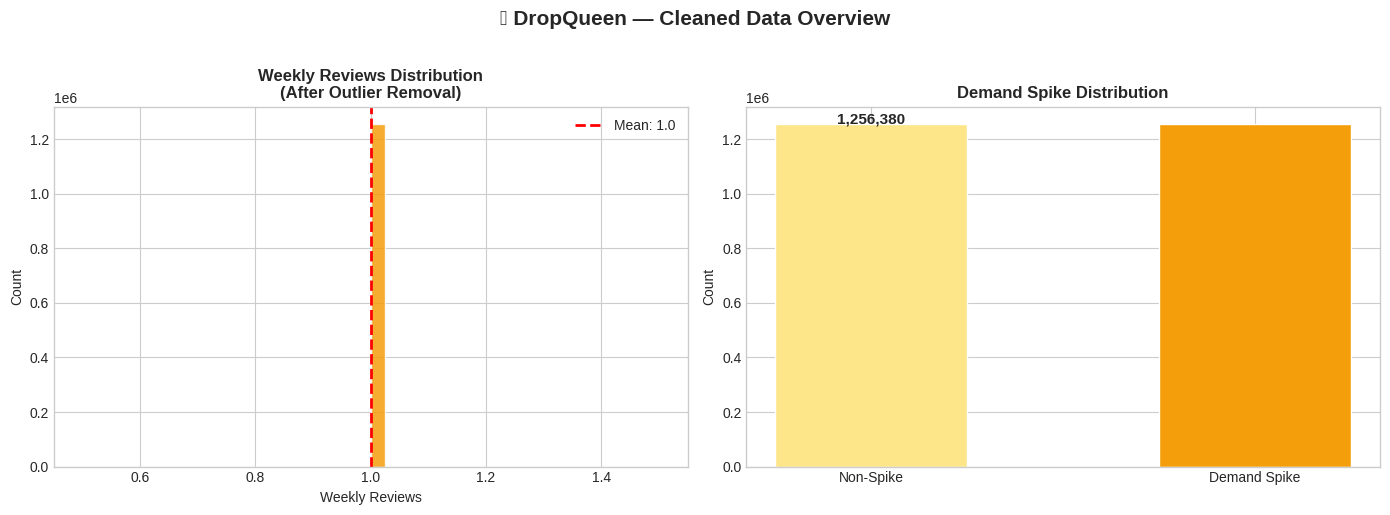

✅ Saved clean_01_demand_distribution.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Weekly reviews distribution
axes[0].hist(df_demand['weekly_reviews'], bins=40,
             color=GOLD, edgecolor='white', alpha=0.85)
axes[0].set_title('Weekly Reviews Distribution\n(After Outlier Removal)', fontweight='bold')
axes[0].set_xlabel('Weekly Reviews')
axes[0].set_ylabel('Count')
axes[0].axvline(df_demand['weekly_reviews'].mean(), color='red',
                linestyle='--', linewidth=2,
                label=f'Mean: {df_demand["weekly_reviews"].mean():.1f}')
axes[0].legend()

# Demand spike distribution
spike_counts = df_demand['demand_spike'].value_counts()
axes[1].bar(['Non-Spike', 'Demand Spike'], spike_counts.sort_index().values,
            color=[LIGHT, GOLD], edgecolor='white', width=0.5)
for i, count in enumerate(spike_counts.sort_index().values):
    axes[1].text(i, count + 100, f'{count:,}',
                ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Demand Spike Distribution', fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('👑 DropQueen — Cleaned Data Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('clean_01_demand_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved clean_01_demand_distribution.png')

## Step 6: Feature Engineering for ML

In [12]:
# Feature 1: Rolling average demand (3-week window per product)
df_demand = df_demand.sort_values(['product_id', 'year', 'week'])
df_demand['rolling_avg_3w'] = df_demand.groupby('product_id')['weekly_reviews'].transform(
    lambda x: x.rolling(window=3, min_periods=1).mean()
)

# Feature 2: Week of year as cyclical feature
df_demand['week_sin'] = np.sin(2 * np.pi * df_demand['week'] / 52)
df_demand['week_cos'] = np.cos(2 * np.pi * df_demand['week'] / 52)

# Feature 3: Is high rating week (avg rating >= 4.0)
df_demand['high_rating_week'] = (df_demand['avg_weekly_rating'] >= 4.0).astype(int)

# Feature 4: Encode product_id as number
le = LabelEncoder()
df_demand['product_encoded'] = le.fit_transform(df_demand['product_id'])

print('✅ New features engineered:')
print('   - rolling_avg_3w       (3-week rolling average demand)')
print('   - week_sin / week_cos  (cyclical week encoding)')
print('   - high_rating_week     (binary: avg rating >= 4.0)')
print('   - product_encoded      (numeric product ID)')
print(f'\n📊 Final demand dataset shape: {df_demand.shape}')
df_demand.head()

✅ New features engineered:
   - rolling_avg_3w       (3-week rolling average demand)
   - week_sin / week_cos  (cyclical week encoding)
   - high_rating_week     (binary: avg rating >= 4.0)
   - product_encoded      (numeric product ID)

📊 Final demand dataset shape: (1256380, 11)


,product_id,year,week,weekly_reviews,avg_weekly_rating,demand_spike,rolling_avg_3w,week_sin,week_cos,high_rating_week,product_encoded
0,0205616461,2013,22,1,5.0000,1,1.0000,0.4647,-0.8855,1,0
1,0558925278,2012,50,1,3.0000,1,1.0000,-0.2393,0.9709,0,1
2,0558925278,2014,28,1,5.0000,1,1.0000,-0.2393,-0.9709,1,1
3,0733001998,2013,43,1,4.0000,1,1.0000,-0.8855,0.4647,1,2
4,0737104473,2010,20,1,1.0000,1,1.0000,0.6631,-0.7485,0,3


## Step 7: Normalize Numeric Features

In [13]:
# Normalize numeric features to 0-1 range
scaler = MinMaxScaler()
cols_to_scale = ['weekly_reviews', 'avg_weekly_rating', 'rolling_avg_3w']
df_demand[cols_to_scale] = scaler.fit_transform(df_demand[cols_to_scale])

print('✅ Normalization complete!')
print('   Columns scaled to 0-1 range:')
for col in cols_to_scale:
    print(f'   {col}: min={df_demand[col].min():.4f}, max={df_demand[col].max():.4f}')

✅ Normalization complete!
   Columns scaled to 0-1 range:
   weekly_reviews: min=0.0000, max=0.0000
   avg_weekly_rating: min=0.0000, max=1.0000
   rolling_avg_3w: min=0.0000, max=0.0000


## Step 8: Clean TikTok Dataset

In [14]:
print('🔍 TikTok Before Cleaning:')
print(f'   Rows:       {len(df_tiktok):,}')
print(f'   Duplicates: {df_tiktok.duplicated().sum():,}')
print(f'   Missing:\n{df_tiktok.isnull().sum()}')

# Remove duplicates
df_tiktok = df_tiktok.drop_duplicates()

# Fill missing numeric with median
for col in df_tiktok.select_dtypes(include=np.number).columns:
    df_tiktok[col] = df_tiktok[col].fillna(df_tiktok[col].median())

# Fill missing text with Unknown
for col in df_tiktok.select_dtypes(include='object').columns:
    df_tiktok[col] = df_tiktok[col].fillna('Unknown')

# Encode Engagement_Level
if 'Engagement_Level' in df_tiktok.columns:
    engagement_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_tiktok['engagement_level_num'] = df_tiktok['Engagement_Level'].map(engagement_map)

print(f'\n✅ TikTok After Cleaning:')
print(f'   Rows:    {len(df_tiktok):,}')
print(f'   Missing: {df_tiktok.isnull().sum().sum():,}')

🔍 TikTok Before Cleaning:
   Rows:       1,260
   Duplicates: 0
   Missing:
Post_ID             0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Views               0
Likes               0
Shares              0
Comments            0
Engagement_Level    0
dtype: int64

✅ TikTok After Cleaning:
   Rows:    1,260
   Missing: 0


## Step 9: Final Quality Check

In [15]:
print('=' * 55)
print('    👑 DropQueen — Final Data Quality Check')
print('=' * 55)
print(f'\n📦 Amazon Dataset:')
print(f'   Rows:      {len(df_amazon):,}')
print(f'   Missing:   {df_amazon.isnull().sum().sum()}')
print(f'   Dupes:     {df_amazon.duplicated().sum()}')
print(f'\n📈 Weekly Demand Dataset:')
print(f'   Rows:      {len(df_demand):,}')
print(f'   Features:  {df_demand.shape[1]}')
print(f'   Missing:   {df_demand.isnull().sum().sum()}')
print(f'   Spike rate:{df_demand["demand_spike"].mean()*100:.1f}%')
print(f'\n📱 TikTok Dataset:')
print(f'   Rows:      {len(df_tiktok):,}')
print(f'   Features:  {df_tiktok.shape[1]}')
print(f'   Missing:   {df_tiktok.isnull().sum().sum()}')
print('\n' + '=' * 55)

    👑 DropQueen — Final Data Quality Check

📦 Amazon Dataset:
   Rows:      2,023,070
   Missing:   0
   Dupes:     0

📈 Weekly Demand Dataset:
   Rows:      1,256,380
   Features:  11
   Missing:   0
   Spike rate:100.0%

📱 TikTok Dataset:
   Rows:      1,260
   Features:  11
   Missing:   0



## Step 10: Save Clean Datasets

In [16]:
# Save all clean datasets
df_amazon.to_csv('dropqueen_amazon_clean.csv', index=False)
df_demand.to_csv('dropqueen_demand_clean.csv', index=False)
df_tiktok.to_csv('dropqueen_tiktok_clean.csv', index=False)

print('✅ Clean datasets saved:')
print('   - dropqueen_amazon_clean.csv')
print('   - dropqueen_demand_clean.csv')
print('   - dropqueen_tiktok_clean.csv')
print(f'\n📁 Charts created:')
print('   - clean_01_demand_distribution.png')
print(f'\n✅ Next: Notebook 03 — ML Model Training')

✅ Clean datasets saved:
   - dropqueen_amazon_clean.csv
   - dropqueen_demand_clean.csv
   - dropqueen_tiktok_clean.csv

📁 Charts created:
   - clean_01_demand_distribution.png

✅ Next: Notebook 03 — ML Model Training
